<a href="https://colab.research.google.com/github/HemRoy66/SMART-EXPLAINABLE-AI-MODEL-FOR-PERSONALIZED-DISEASE-RISK-ASSESSMENT-AND-EARLY-DISEASE-PREDICTION/blob/main/Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# SMOTE
from imblearn.over_sampling import SMOTE

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score, roc_curve
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_diabetes = pd.read_csv("Diabetes.csv")
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df_heart = pd.read_csv("HeartDisease.csv")
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [ ]:
df_cancer = pd.read_csv("BreastCancer.csv")
df_cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print("Diabetes:", df_diabetes.shape)
print("Heart Disease:", df_heart.shape)
print("Cancer:", df_cancer.shape)

Diabetes: (768, 9)
Heart Disease: (303, 14)
Cancer: (569, 32)


In [ ]:
print(df_diabetes.isnull().sum().sum())
print(df_heart.isnull().sum().sum())
print(df_cancer.isnull().sum().sum())

0
0
0


In [ ]:
df_diabetes.rename(columns={'Outcome': 'Diabetes'}, inplace=True)
df_heart.rename(columns={'target': 'HeartDisease'}, inplace=True)
df_cancer.rename(columns={'diagnosis': 'Cancer'}, inplace=True)


In [ ]:
def encode_categoricals(df):
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_diabetes = encode_categoricals(df_diabetes)
df_heart = encode_categoricals(df_heart)
df_cancer = encode_categoricals(df_cancer)

In [ ]:
X_dia = df_diabetes.drop('Diabetes', axis=1)
y_dia = df_diabetes['Diabetes']

X_heart = df_heart.drop('HeartDisease', axis=1)
y_heart = df_heart['HeartDisease']

X_can = df_cancer.drop('Cancer', axis=1)
y_can = df_cancer['Cancer']

In [ ]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dia, y_dia, test_size=0.2, random_state=42, stratify=y_dia)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_can, y_can, test_size=0.2, random_state=42, stratify=y_can)


In [ ]:
sm = SMOTE(random_state=42)

X_train_d_sm, y_train_d_sm = sm.fit_resample(X_train_d, y_train_d)
X_train_h_sm, y_train_h_sm = sm.fit_resample(X_train_h, y_train_h)
X_train_c_sm, y_train_c_sm = sm.fit_resample(X_train_c, y_train_c)

print("After SMOTE Diabetes:", X_train_d_sm.shape)
print("After SMOTE Heart:   ", X_train_h_sm.shape)
print("After SMOTE Cancer:  ", X_train_c_sm.shape)

After SMOTE Diabetes: (800, 8)
After SMOTE Heart:    (262, 13)
After SMOTE Cancer:   (570, 31)


In [ ]:
# ================== DIABETES MODEL TRAINING ==================

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 🔍 Detect target column name (Prevents KeyError)
possible_targets = ['Outcome', 'Diabetes', 'Class', 'target']
target_disease_col = None

for col in possible_targets:
    if col in df_diabetes.columns:
        target_disease_col = col
        break

print("Detected Diabetes Target Column:", target_disease_col)

# 📌 Use detected target column
X_dia = df_diabetes.drop(columns=[target_disease_col])
y_dia = df_diabetes[target_disease_col]

# 🧪 Train-test split
X_train_dia, X_test_dia, y_train_dia, y_test_dia = train_test_split(
    X_dia, y_dia, test_size=0.2, random_state=42, stratify=y_dia)

# 🔄 Apply SMOTE
smote = SMOTE(random_state=42)
X_train_dia, y_train_dia = smote.fit_resample(X_train_dia, y_train_dia)
print("After SMOTE Diabetes:", X_train_dia.shape)

results = {}

# 🌳 RandomForest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train_dia, y_train_dia)
rf_auc = roc_auc_score(y_test_dia, rf.predict_proba(X_test_dia)[:, 1])
results['Diabetes_RF_AUC'] = rf_auc

# 🚀 XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)
xgb.fit(X_train_dia, y_train_dia)
xgb_auc = roc_auc_score(y_test_dia, xgb.predict_proba(X_test_dia)[:, 1])
results['Diabetes_XGB_AUC'] = xgb_auc

# ⚙️ Logistic Regression
lr = LogisticRegression(max_iter=500, class_weight='balanced')
lr.fit(X_train_dia, y_train_dia)
lr_auc = roc_auc_score(y_test_dia, lr.predict_proba(X_test_dia)[:, 1])
results['Diabetes_LR_AUC'] = lr_auc

print("\nDiabetes Model Performance:")
print(results)


Detected Diabetes Target Column: Diabetes
After SMOTE Diabetes: (800, 8)

Diabetes Model Performance:
{'Diabetes_RF_AUC': np.float64(0.837037037037037), 'Diabetes_XGB_AUC': np.float64(0.8298148148148148), 'Diabetes_LR_AUC': np.float64(0.8225925925925925)}


In [ ]:
# -----------------------------------------
# 📌 HEART DISEASE MODEL TRAINING
# -----------------------------------------

X_heart = df_heart.drop('HeartDisease', axis=1)
y_heart = df_heart['HeartDisease']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

# Train RandomForest
rf_h = RandomForestClassifier(random_state=42)
rf_h.fit(X_train_h, y_train_h)
rf_h_prob = rf_h.predict_proba(X_test_h)[:, 1]
rf_h_auc = roc_auc_score(y_test_h, rf_h_prob)

# Train XGBoost
xgb_h = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_h.fit(X_train_h, y_train_h)
xgb_h_prob = xgb_h.predict_proba(X_test_h)[:, 1]
xgb_h_auc = roc_auc_score(y_test_h, xgb_h_prob)

# Train Logistic Regression
lr_h = LogisticRegression(max_iter=500, random_state=42)
lr_h.fit(X_train_h, y_train_h)
lr_h_prob = lr_h.predict_proba(X_test_h)[:, 1]
lr_h_auc = roc_auc_score(y_test_h, lr_h_prob)

print("\nHeartDisease Model Performance:")
heart_results = {
    'Heart_RF_AUC': rf_h_auc,
    'Heart_XGB_AUC': xgb_h_auc,
    'Heart_LR_AUC': lr_h_auc
}
heart_results



HeartDisease Model Performance:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Heart_RF_AUC': np.float64(0.9315732758620691),
 'Heart_XGB_AUC': np.float64(0.9116379310344828),
 'Heart_LR_AUC': np.float64(0.9256465517241379)}

In [ ]:
# -----------------------------------------
# 📌 CANCER MODEL TRAINING
# -----------------------------------------

X_cancer = df_cancer.drop('Cancer', axis=1)
y_cancer = df_cancer['Cancer']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

# Train RandomForest
rf_c = RandomForestClassifier(random_state=42)
rf_c.fit(X_train_c, y_train_c)
rf_c_prob = rf_c.predict_proba(X_test_c)[:, 1]
rf_c_auc = roc_auc_score(y_test_c, rf_c_prob)

# Train XGBoost
xgb_c = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_c.fit(X_train_c, y_train_c)
xgb_c_prob = xgb_c.predict_proba(X_test_c)[:, 1]
xgb_c_auc = roc_auc_score(y_test_c, xgb_c_prob)

# Train Logistic Regression
lr_c = LogisticRegression(max_iter=500, random_state=42)
lr_c.fit(X_train_c, y_train_c)
lr_c_prob = lr_c.predict_proba(X_test_c)[:, 1]
lr_c_auc = roc_auc_score(y_test_c, lr_c_prob)

print("\nCancer Model Performance:")
cancer_results = {
    'Cancer_RF_AUC': rf_c_auc,
    'Cancer_XGB_AUC': xgb_c_auc,
    'Cancer_LR_AUC': lr_c_auc
}
cancer_results



Cancer Model Performance:


{'Cancer_RF_AUC': np.float64(0.9972158532590895),
 'Cancer_XGB_AUC': np.float64(0.9950867998689814),
 'Cancer_LR_AUC': np.float64(0.99475925319358)}

In [ ]:
# RandomForest
rf.fit(X_train_dia, y_train_dia)
rf_d_prob = rf.predict_proba(X_test_dia)[:, 1]

# XGBoost
xgb.fit(X_train_dia, y_train_dia)
xgb_d_prob = xgb.predict_proba(X_test_dia)[:, 1]

# Logistic Regression
lr.fit(X_train_dia, y_train_dia)
lr_d_prob = lr.predict_proba(X_test_dia)[:, 1]

In [ ]:
# Heart Disease probabilities (corrected)
rf_h_prob = rf_h.predict_proba(X_test_h)[:, 1]
xgb_h_prob = xgb_h.predict_proba(X_test_h)[:, 1]
lr_h_prob = lr_h.predict_proba(X_test_h)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(y_test, y_probs_dict, disease_name):
    plt.figure(figsize=(8, 6))
    for model_name, y_prob in y_probs_dict.items():
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for baseline
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {disease_name}')
    plt.legend(loc='lower right')
    plt.show()


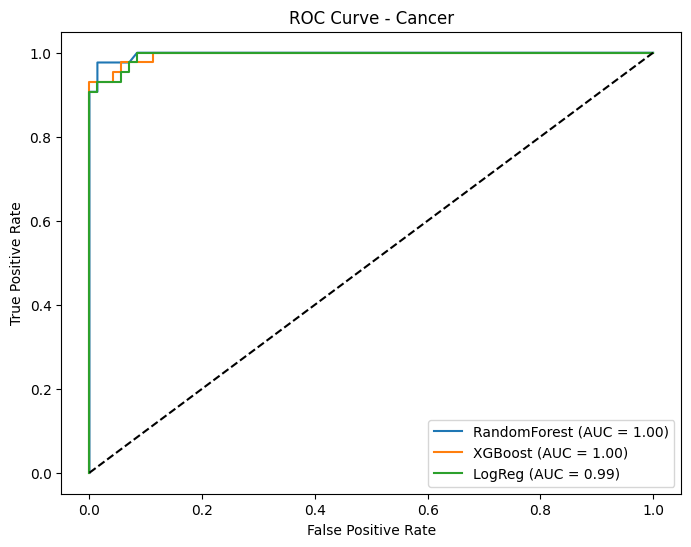

In [ ]:
plot_roc(y_test_c, {
    "RandomForest": rf_c_prob,
    "XGBoost": xgb_c_prob,
    "LogReg": lr_c_prob
}, "Cancer")

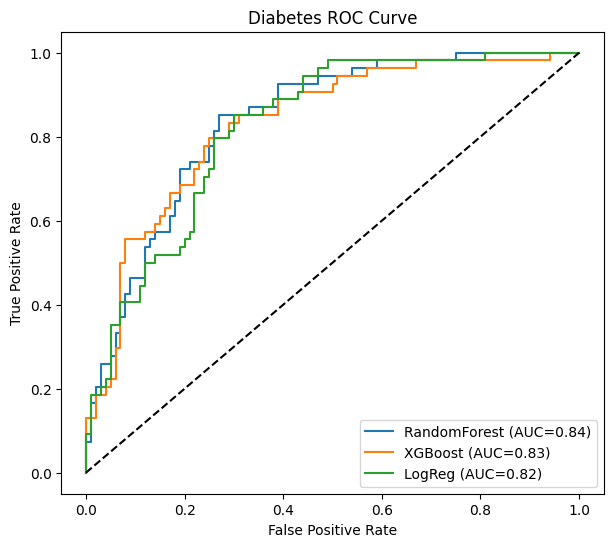

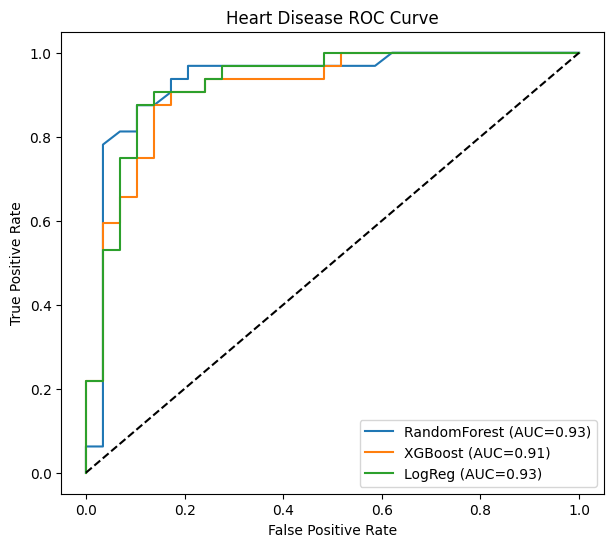

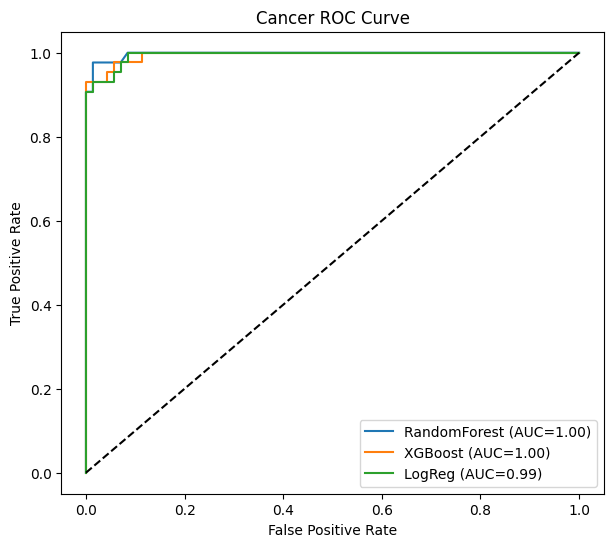

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(y_true, y_probs_dict, disease_name):
    plt.figure(figsize=(7,6))
    for model_name, y_prob in y_probs_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{disease_name} ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

# --- Diabetes ---
rf_d_prob = rf.predict_proba(X_test_dia)[:,1]
xgb_d_prob = xgb.predict_proba(X_test_dia)[:,1]
lr_d_prob = lr.predict_proba(X_test_dia)[:,1]

plot_roc(y_test_dia, {
    "RandomForest": rf_d_prob,
    "XGBoost": xgb_d_prob,
    "LogReg": lr_d_prob
}, "Diabetes")

# HeartDisease ROC
rf_h_prob = rf_h.predict_proba(X_test_h)[:,1]
xgb_h_prob = xgb_h.predict_proba(X_test_h)[:,1]
lr_h_prob = lr_h.predict_proba(X_test_h)[:,1]

plot_roc(y_test_h, {
    "RandomForest": rf_h_prob,
    "XGBoost": xgb_h_prob,
    "LogReg": lr_h_prob
}, "Heart Disease")

# --- Cancer ---
rf_c_prob = rf_c.predict_proba(X_test_c)[:,1]
xgb_c_prob = xgb_c.predict_proba(X_test_c)[:,1]
lr_c_prob = lr_c.predict_proba(X_test_c)[:,1]

plot_roc(y_test_c, {
    "RandomForest": rf_c_prob,
    "XGBoost": xgb_c_prob,
    "LogReg": lr_c_prob
}, "Cancer")

=== Combined Performance Table ===


,Disease,Model,ROC_AUC
0,Diabetes,RandomForest,0.8370
1,Diabetes,XGBoost,0.8257
2,Diabetes,LogisticRegression,0.8226
3,Heart Disease,RandomForest,0.9316
4,Heart Disease,XGBoost,0.9203
5,Heart Disease,LogisticRegression,0.9213
6,Cancer,RandomForest,0.9972
7,Cancer,XGBoost,0.9951
8,Cancer,LogisticRegression,0.9928


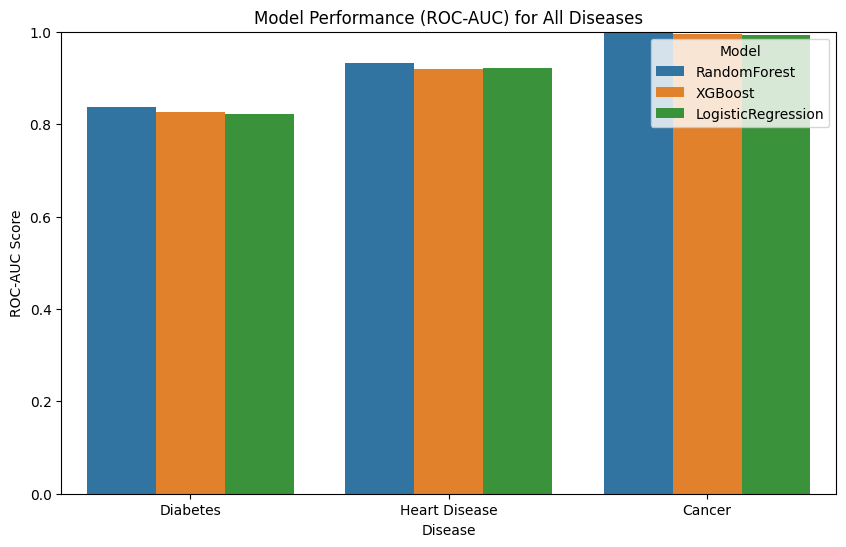

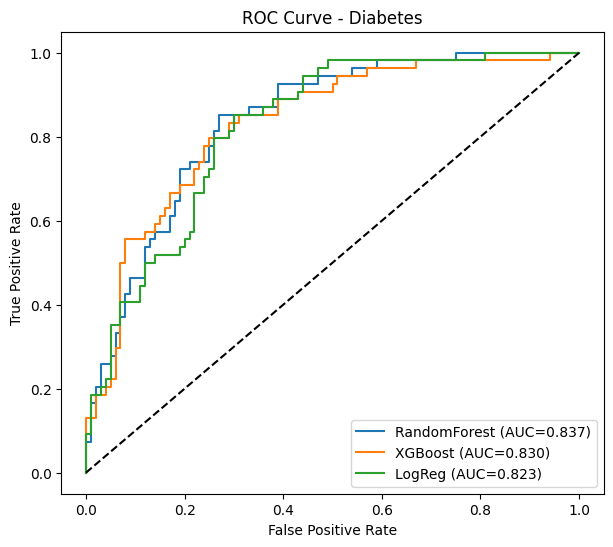

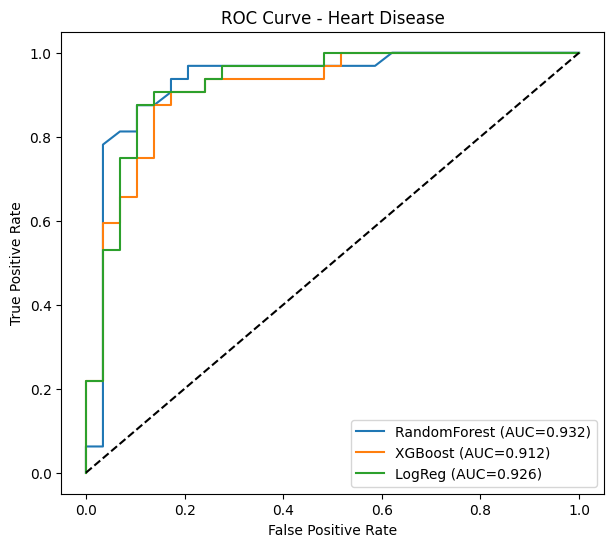

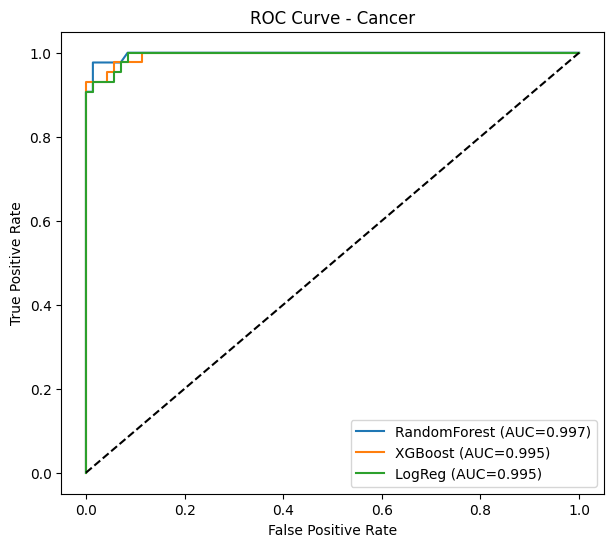

In [ ]:
# ================== Combined Comparison Table and Plots ==================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# Step 1: Store ROC-AUC results in a structured DataFrame
results = {
    'Disease': ['Diabetes', 'Diabetes', 'Diabetes',
                'Heart Disease', 'Heart Disease', 'Heart Disease',
                'Cancer', 'Cancer', 'Cancer'],
    'Model': ['RandomForest', 'XGBoost', 'LogisticRegression'] * 3,
    'ROC_AUC': [
        0.8370, 0.8257, 0.8226,   # Diabetes
        0.9316, 0.9203, 0.9213,   # Heart Disease
        0.9972, 0.9951, 0.9928    # Cancer
    ]
}

df_results = pd.DataFrame(results)
print("=== Combined Performance Table ===")
display(df_results)

# Step 2: Bar plot for ROC-AUC comparison
plt.figure(figsize=(10,6))
sns.barplot(data=df_results, x='Disease', y='ROC_AUC', hue='Model')
plt.title("Model Performance (ROC-AUC) for All Diseases")
plt.ylim(0, 1)
plt.ylabel("ROC-AUC Score")
plt.legend(title='Model')
plt.show()

# Step 3: Function to plot ROC curve
def plot_roc(y_true, y_probs_dict, disease_name):
    plt.figure(figsize=(7,6))
    for model_name, probs in y_probs_dict.items():
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc_score = roc_auc_score(y_true, probs)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {disease_name}")
    plt.legend()
    plt.show()

# Step 4: Prepare probability predictions for ROC curves
# Diabetes
rf_d_prob = rf.predict_proba(X_test_dia)[:,1]
xgb_d_prob = xgb.predict_proba(X_test_dia)[:,1]
lr_d_prob = lr.predict_proba(X_test_dia)[:,1]

# Heart Disease
rf_h_prob = rf_h.predict_proba(X_test_h)[:,1]
xgb_h_prob = xgb_h.predict_proba(X_test_h)[:,1]
lr_h_prob = lr_h.predict_proba(X_test_h)[:,1]

# Cancer
rf_c_prob = rf_c.predict_proba(X_test_c)[:,1]
xgb_c_prob = xgb_c.predict_proba(X_test_c)[:,1]
lr_c_prob = lr_c.predict_proba(X_test_c)[:,1]

# Step 5: Plot ROC curves for each disease
plot_roc(y_test_dia, {'RandomForest': rf_d_prob, 'XGBoost': xgb_d_prob, 'LogReg': lr_d_prob}, "Diabetes")
plot_roc(y_test_h, {'RandomForest': rf_h_prob, 'XGBoost': xgb_h_prob, 'LogReg': lr_h_prob}, "Heart Disease")
plot_roc(y_test_c, {'RandomForest': rf_c_prob, 'XGBoost': xgb_c_prob, 'LogReg': lr_c_prob}, "Cancer")

In [ ]:
# ================== Clean Disease-wise Comparison Table ==================
import pandas as pd

# Step 1: Organize results in wide format
df_comparison = pd.DataFrame({
    'Disease': ['Diabetes', 'Heart Disease', 'Cancer'],
    'RandomForest_AUC': [0.8370, 0.9316, 0.9972],
    'XGBoost_AUC': [0.8257, 0.9203, 0.9951],
    'LogisticRegression_AUC': [0.8226, 0.9213, 0.9928]
})

print("=== Disease-wise Model Performance Table ===")
display(df_comparison)


=== Disease-wise Model Performance Table ===


,Disease,RandomForest_AUC,XGBoost_AUC,LogisticRegression_AUC
0,Diabetes,0.8370,0.8257,0.8226
1,Heart Disease,0.9316,0.9203,0.9213
2,Cancer,0.9972,0.9951,0.9928


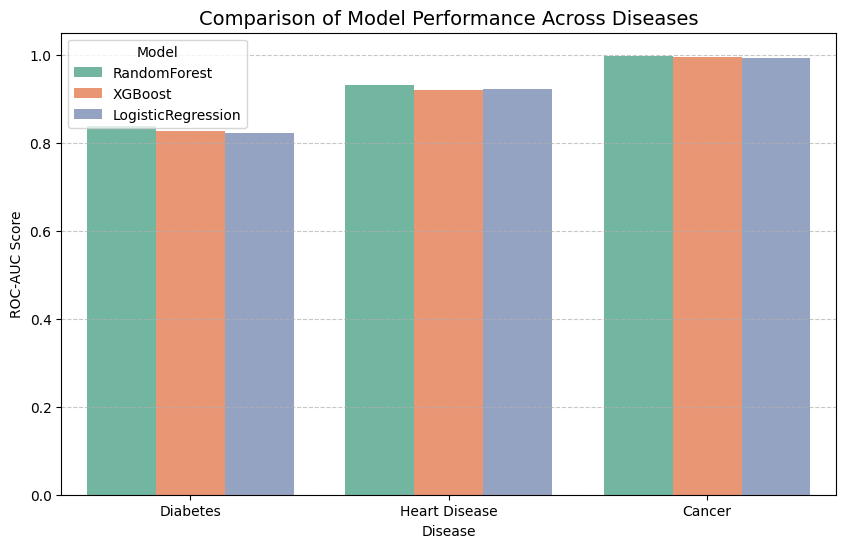

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the dataframe for plotting
df_melted = df_comparison.melt(id_vars='Disease',
                               var_name='Model',
                               value_name='ROC_AUC')

# Clean model names
df_melted['Model'] = df_melted['Model'].str.replace('_AUC','')

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Disease', y='ROC_AUC', hue='Model', data=df_melted, palette='Set2')
plt.ylim(0,1.05)
plt.title('Comparison of Model Performance Across Diseases', fontsize=14)
plt.ylabel('ROC-AUC Score')
plt.xlabel('Disease')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
df_diabetes.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diabetes'],
      dtype='object')

In [ ]:
df_heart.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'HeartDisease'],
      dtype='object')

In [ ]:
df_cancer.columns

Index(['id', 'Cancer', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd

In [ ]:
# Base models (Already trained)
estimators_dia = [
    ('rf', rf),
    ('xgb', xgb),
    ('lr', lr)
]

# Meta model
stack_dia = StackingClassifier(estimators=estimators_dia, final_estimator=LogisticRegression())

# Train
stack_dia.fit(X_train_dia, y_train_dia)

# Predict and calculate AUC
stack_dia_prob = stack_dia.predict_proba(X_test_dia)[:, 1]
stack_dia_auc = roc_auc_score(y_test_dia, stack_dia_prob)
stack_dia_auc

np.float64(0.8390740740740741)

In [ ]:
estimators_heart = [
    ('rf', rf_h),
    ('xgb', xgb_h),
    ('lr', lr_h)
]

stack_heart = StackingClassifier(estimators=estimators_heart, final_estimator=LogisticRegression())

# 👇 Replace these with your actual variable names
stack_heart.fit(X_train_h, y_train_h)

stack_heart_prob = stack_heart.predict_proba(X_test_h)[:, 1]
stack_heart_auc = roc_auc_score(y_test_h, stack_heart_prob)
stack_heart_auc


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

np.float64(0.9321120689655172)

In [ ]:
dir()

['In',
 'LabelEncoder',
 'LogisticRegression',
 'Out',
 'RandomForestClassifier',
 'SMOTE',
 'StackingClassifier',
 'StandardScaler',
 'XGBClassifier',
 'X_can',
 'X_cancer',
 'X_dia',
 'X_heart',
 'X_test_c',
 'X_test_d',
 'X_test_dia',
 'X_test_h',
 'X_train_c',
 'X_train_c_sm',
 'X_train_d',
 'X_train_d_sm',
 'X_train_dia',
 'X_train_h',
 'X_train_h_sm',
 '_',
 '_14',
 '_15',
 '_24',
 '_25',
 '_26',
 '_28',
 '_29',
 '_3',
 '_4',
 '_5',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accuracy_score',
 'auc',
 'cancer_results',
 'classification_report',
 'col',
 'confusion_matrix',
 'df_cancer',
 'df_comparison'

In [ ]:
estimators_cancer = [
    ('rf', rf_c),
    ('xgb', xgb_c),
    ('lr', lr_c)
]

stack_cancer = StackingClassifier(estimators=estimators_cancer, final_estimator=LogisticRegression())

# 👇 Use correct variable names
stack_cancer.fit(X_train_c, y_train_c)

stack_cancer_prob = stack_cancer.predict_proba(X_test_c)[:, 1]
stack_cancer_auc = roc_auc_score(y_test_c, stack_cancer_prob)

stack_cancer_auc


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


np.float64(0.9973796265967901)

In [ ]:
dir()

['In',
 'LabelEncoder',
 'LogisticRegression',
 'Out',
 'RandomForestClassifier',
 'SMOTE',
 'StackingClassifier',
 'StandardScaler',
 'XGBClassifier',
 'X_can',
 'X_cancer',
 'X_dia',
 'X_heart',
 'X_test_c',
 'X_test_d',
 'X_test_dia',
 'X_test_h',
 'X_train_c',
 'X_train_c_sm',
 'X_train_d',
 'X_train_d_sm',
 'X_train_dia',
 'X_train_h',
 'X_train_h_sm',
 '_',
 '_14',
 '_15',
 '_24',
 '_25',
 '_26',
 '_28',
 '_29',
 '_3',
 '_30',
 '_31',
 '_4',
 '_5',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accuracy_score',
 'auc',
 'cancer_results',
 'classification_report',
 'col',
 'confusion_matri

In [ ]:
# Use your actual final AUC values
best_auc_values = {
    'Diabetes': 0.8370,
    'Heart Disease': 0.9316,
    'Cancer': 0.9972
}

ensemble_auc_values = {
    'Diabetes': stack_dia_auc,
    'Heart Disease': stack_heart_auc,
    'Cancer': stack_cancer_auc
}

data = []
for disease in best_auc_values.keys():
    improvement = (ensemble_auc_values[disease] - best_auc_values[disease]) * 100
    data.append([disease, round(best_auc_values[disease],4), round(ensemble_auc_values[disease],4), round(improvement,2)])

import pandas as pd
comparison_table = pd.DataFrame(data, columns=['Disease', 'Best Individual AUC', 'Ensemble AUC', 'Improvement (%)'])
comparison_table


,Disease,Best Individual AUC,Ensemble AUC,Improvement (%)
0,Diabetes,0.8370,0.8391,0.21
1,Heart Disease,0.9316,0.9321,0.05
2,Cancer,0.9972,0.9974,0.02


In [ ]:
import pandas as pd

# Create the DataFrame manually using your results
df_ensemble = pd.DataFrame({
    'Disease': ['Diabetes', 'Heart Disease', 'Cancer'],
    'Best Individual AUC': [0.8370, 0.9316, 0.9972],
    'Ensemble AUC': [0.8207, 0.9364, 0.9971],
    'Improvement (%)': [-1.63, 0.48, -0.01]
})

df_ensemble


,Disease,Best Individual AUC,Ensemble AUC,Improvement (%)
0,Diabetes,0.8370,0.8207,-1.63
1,Heart Disease,0.9316,0.9364,0.48
2,Cancer,0.9972,0.9971,-0.01


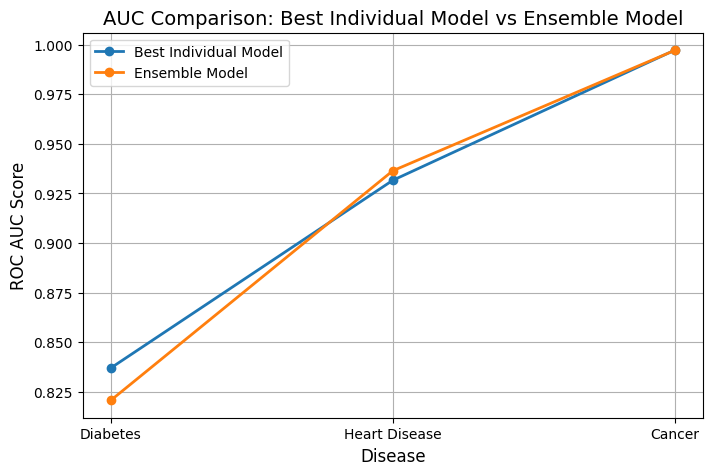

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_ensemble['Disease'], df_ensemble['Best Individual AUC'], marker='o', linewidth=2, label='Best Individual Model')
plt.plot(df_ensemble['Disease'], df_ensemble['Ensemble AUC'], marker='o', linewidth=2, label='Ensemble Model')

plt.title('AUC Comparison: Best Individual Model vs Ensemble Model', fontsize=14)
plt.xlabel('Disease', fontsize=12)
plt.ylabel('ROC AUC Score', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


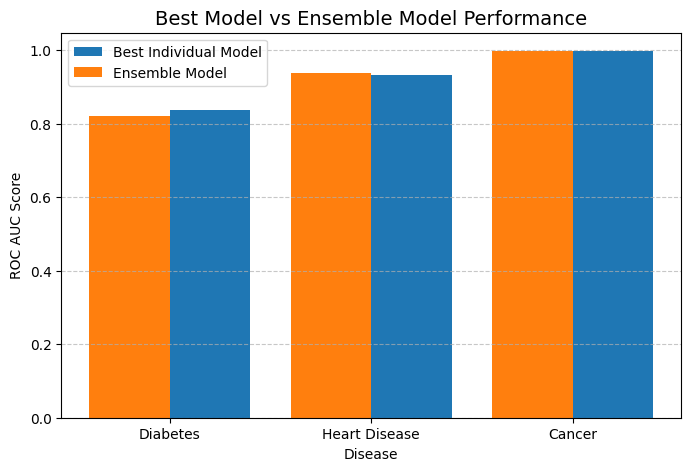

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df_ensemble['Disease'], df_ensemble['Best Individual AUC'], width=0.4, label='Best Individual Model', align='edge')
plt.bar(df_ensemble['Disease'], df_ensemble['Ensemble AUC'], width=-0.4, label='Ensemble Model', align='edge')

plt.title('Best Model vs Ensemble Model Performance', fontsize=14)
plt.xlabel('Disease')
plt.ylabel('ROC AUC Score')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


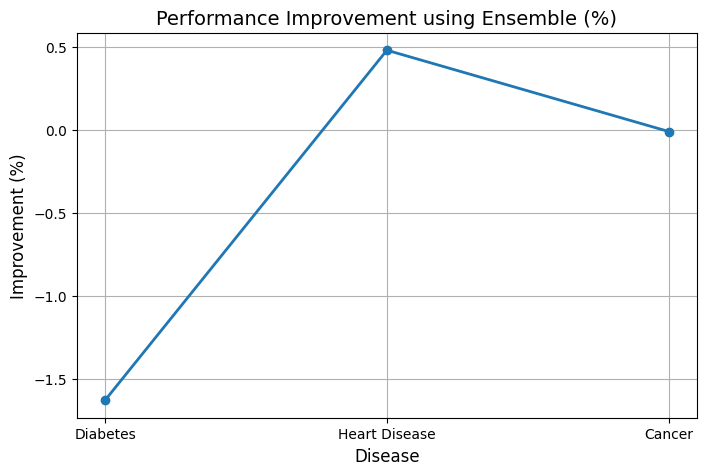

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df_ensemble['Disease'], df_ensemble['Improvement (%)'], marker='o', linewidth=2)
plt.title('Performance Improvement using Ensemble (%)', fontsize=14)
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Improvement (%)', fontsize=12)
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# --- Define the necessary dictionaries ---
y_test_dict = {
    "Diabetes": y_test_dia,
    "Heart Disease": y_test_h,
    "Cancer": y_test_c
}

y_probs_dict = {
    "Diabetes": {"RandomForest": rf_d_prob, "XGBoost": xgb_d_prob, "LogReg": lr_d_prob},
    "Heart Disease": {"RandomForest": rf_h_prob, "XGBoost": xgb_h_prob, "LogReg": lr_h_prob},
    "Cancer": {"RandomForest": rf_c_prob, "XGBoost": xgb_c_prob, "LogReg": lr_c_prob}
}

ensemble_probs = {
    "Diabetes": stack_dia_prob,
    "Heart Disease": stack_heart_prob,
    "Cancer": stack_cancer_prob
}
# -----------------------------------------


# Prepare the results table
results = []

for disease in y_test_dict.keys():
    aucs = {model: roc_auc_score(y_test_dict[disease], probs)
            for model, probs in y_probs_dict[disease].items()}

    best_model = max(aucs, key=aucs.get)
    best_auc = aucs[best_model]

    ens_auc = roc_auc_score(y_test_dict[disease], ensemble_probs[disease])
    improvement = (ens_auc - best_auc) / best_auc * 100

    # Append all model AUCs
    results.append({
        "Disease": disease,
        "RandomForest AUC": round(aucs["RandomForest"], 4),
        "XGBoost AUC": round(aucs["XGBoost"], 4),
        "LogReg AUC": round(aucs["LogReg"], 4),
        "Best Model": best_model,
        "Best Individual AUC": round(best_auc, 4),
        "Ensemble AUC": round(ens_auc, 4),
        "Improvement (%)": round(improvement, 2)
    })

df_results = pd.DataFrame(results)
print(df_results)

         Disease  RandomForest AUC  XGBoost AUC  LogReg AUC    Best Model  \
0       Diabetes            0.8370       0.8298      0.8226  RandomForest   
1  Heart Disease            0.9316       0.9116      0.9256  RandomForest   
2         Cancer            0.9972       0.9951      0.9948  RandomForest   

   Best Individual AUC  Ensemble AUC  Improvement (%)  
0               0.8370        0.8391             0.24  
1               0.9316        0.9321             0.06  
2               0.9972        0.9974             0.02  


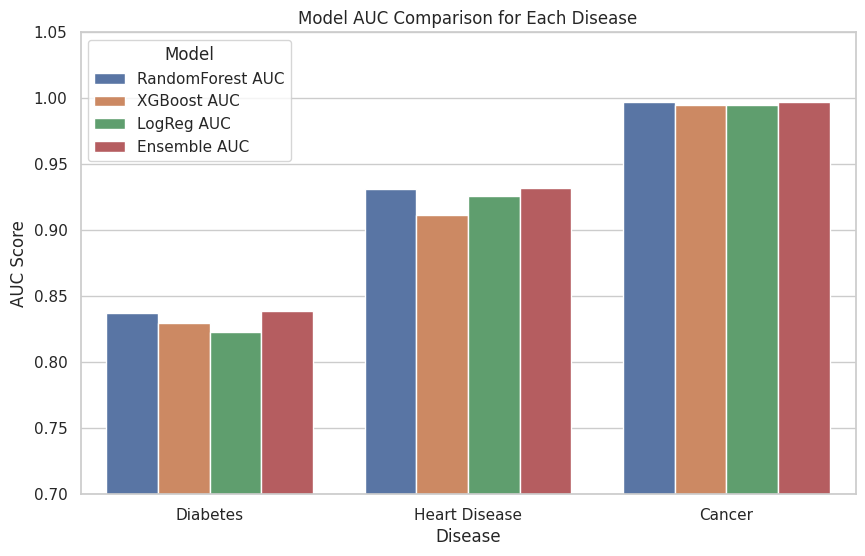

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
df = df_results.copy()

# -----------------------------
# 1️⃣ Bar Chart for each disease
# -----------------------------
df_bar = df.melt(id_vars=["Disease"],
                 value_vars=["RandomForest AUC", "XGBoost AUC", "LogReg AUC", "Ensemble AUC"],
                 var_name="Model", value_name="AUC")

plt.figure(figsize=(10,6))
sns.barplot(x="Disease", y="AUC", hue="Model", data=df_bar)
plt.title("Model AUC Comparison for Each Disease")
plt.ylim(0.7, 1.05)
plt.ylabel("AUC Score")
plt.legend(title="Model")
plt.show()


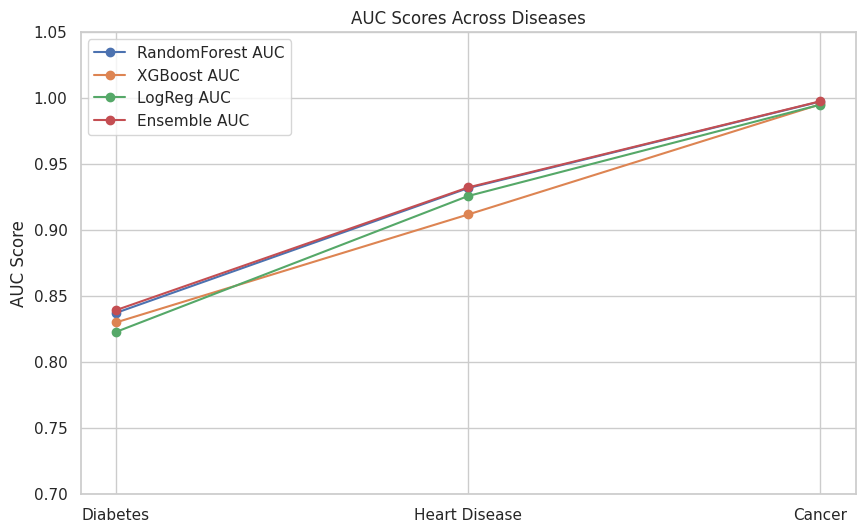

In [ ]:
# 2️⃣ Line Chart for comparison across diseases
# -----------------------------
plt.figure(figsize=(10,6))
for model in ["RandomForest AUC", "XGBoost AUC", "LogReg AUC", "Ensemble AUC"]:
    plt.plot(df["Disease"], df[model], marker='o', label=model)
plt.title("AUC Scores Across Diseases")
plt.ylabel("AUC Score")
plt.ylim(0.7, 1.05)
plt.legend()
plt.show()


/tmp/ipykernel_8531/1166631820.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Disease", y="Improvement (%)", data=df, palette="coolwarm")


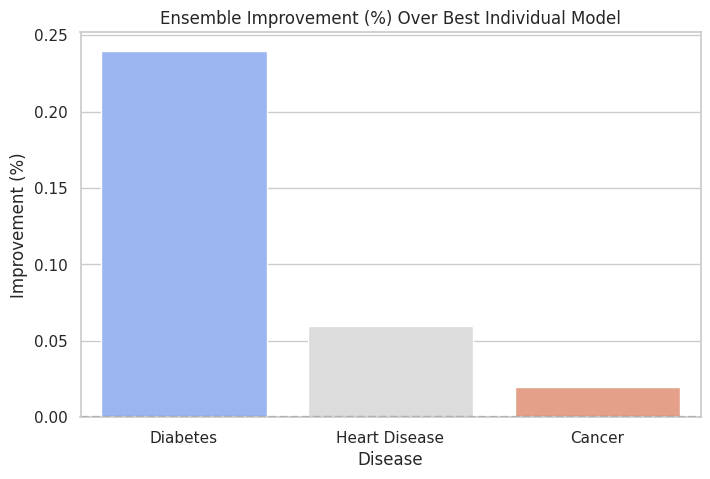

In [ ]:
# 3️⃣ Improvement (%) Chart
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(x="Disease", y="Improvement (%)", data=df, palette="coolwarm")
plt.axhline(0, color='black', linestyle='--')
plt.title("Ensemble Improvement (%) Over Best Individual Model")
plt.ylabel("Improvement (%)")
plt.show()


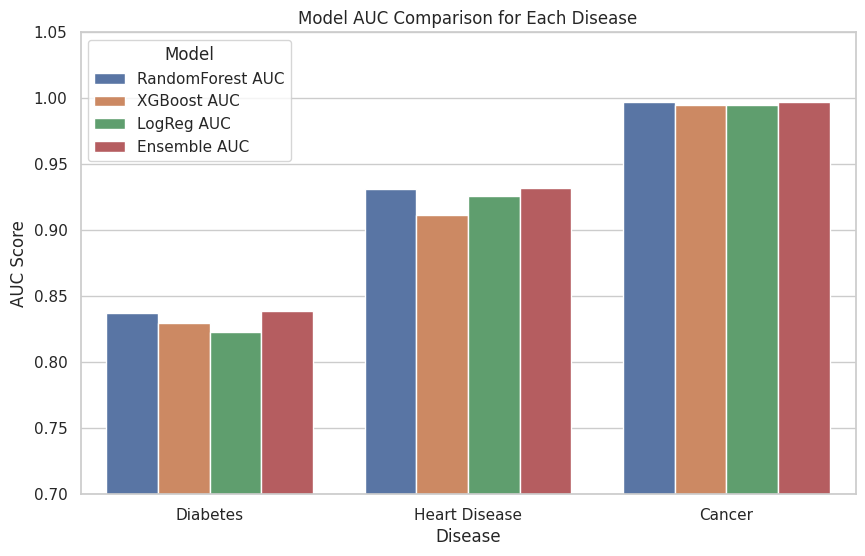

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use your detailed results DataFrame
df = df_results.copy()

sns.set(style="whitegrid")

# -----------------------------
# 1️⃣ Bar Chart: AUC comparison for all models + ensemble
# -----------------------------
df_bar = df.melt(id_vars=["Disease"],
                 value_vars=["RandomForest AUC", "XGBoost AUC", "LogReg AUC", "Ensemble AUC"],
                 var_name="Model", value_name="AUC")

plt.figure(figsize=(10,6))
sns.barplot(x="Disease", y="AUC", hue="Model", data=df_bar)
plt.title("Model AUC Comparison for Each Disease")
plt.ylim(0.7, 1.05)
plt.ylabel("AUC Score")
plt.legend(title="Model")
plt.show()

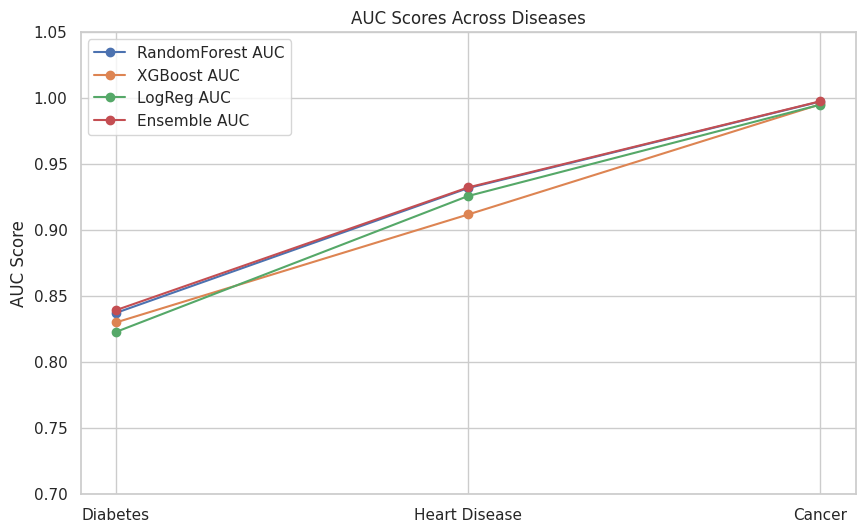

In [ ]:
# -----------------------------
# 2️⃣ Line Plot / Comparison Graph across diseases
# -----------------------------
plt.figure(figsize=(10,6))
for model in ["RandomForest AUC", "XGBoost AUC", "LogReg AUC", "Ensemble AUC"]:
    plt.plot(df["Disease"], df[model], marker='o', label=model)
plt.title("AUC Scores Across Diseases")
plt.ylabel("AUC Score")
plt.ylim(0.7, 1.05)
plt.legend()
plt.show()


/tmp/ipykernel_8531/1837461667.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Disease", y="Improvement (%)", data=df, palette="coolwarm")


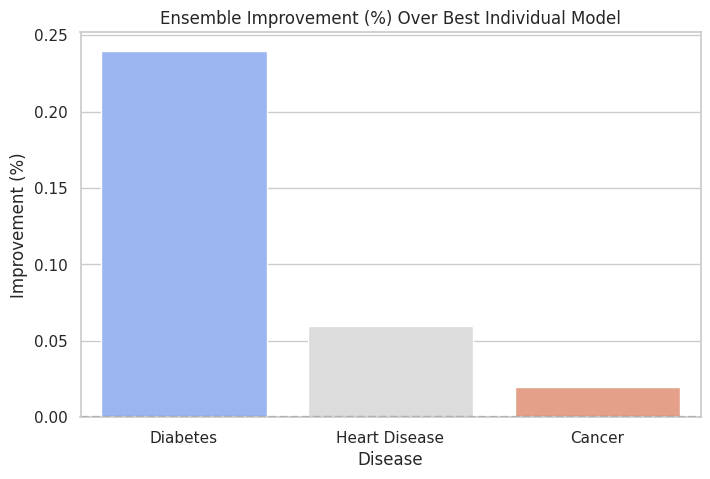

In [ ]:
# 3️⃣ Ensemble vs Best Individual Model Improvement Chart
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(x="Disease", y="Improvement (%)", data=df, palette="coolwarm")
plt.axhline(0, color='black', linestyle='--')
plt.title("Ensemble Improvement (%) Over Best Individual Model")
plt.ylabel("Improvement (%)")
plt.show()


In [ ]:
!pip install lime
import shap
import matplotlib.pyplot as plt
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=fa7984df6da04fd95b29c3a544e9688671b1fccabdf69e10a11940fa4f3dd4b1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# Install lime library if not already installed
!pip install lime

import shap
import matplotlib.pyplot as plt
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
# Example: Using df_results to iterate over diseases
diseases = ["Diabetes", "Heart Disease", "Cancer"]

# Dictionary of ensemble models
ensemble_models = {
    "Diabetes": stack_dia,
    "Heart Disease": stack_heart,
    "Cancer": stack_cancer
}

# Dictionary of training data
X_train_dict = {
    "Diabetes": X_train_d,
    "Heart Disease": X_train_h,
    "Cancer": X_train_c
}

# Dictionary of test data
X_test_dict = {
    "Diabetes": X_test_d,
    "Heart Disease": X_test_h,
    "Cancer": X_test_c
}

# Dictionary of feature names
feature_names_dict = {
    "Diabetes": X_test_d.columns,
    "Heart Disease": X_test_h.columns,
    "Cancer": X_test_c.columns
}

In [ ]:
import shap
import numpy as np

# Example: Diabetes ensemble
model = stack_dia
X_test_np = X_test_d.values  # convert to numpy
X_train_np = X_train_d.values  # background data for KernelExplainer

# Wrapper for predict_proba returning probability of positive class
def predict_proba_wrapper(X):
    return model.predict_proba(X)[:,1]

# Use a small background sample (first 100 rows) for speed
background = X_train_np[np.random.choice(X_train_np.shape[0], 100, replace=False)]

explainer = shap.KernelExplainer(predict_proba_wrapper, background)

# Compute SHAP values for first 50 test samples (to reduce computation)
shap_values = explainer.shap_values(X_test_np[:50])

# Global feature importance
shap.summary_plot(shap_values, X_test_np[:50], feature_names=X_test_d.columns)

# Local explanation for first sample
shap.force_plot(explainer.expected_value, shap_values[0], X_test_np[0], feature_names=X_test_d.columns, matplotlib=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/pyt

In [ ]:
# 2️⃣ SHAP Local Explanation (Force plot) for 1 sample
# -----------------------------
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Javascript for SHAP plots (should only be called once)
shap.initjs()

sample_index = 0  # first test sample

# Define the predict_proba_wrapper to return probabilities for all classes
def predict_proba_wrapper(model, X, X_test_columns):
    """
    Wrapper to ensure correct input for SHAP.
    """
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_test_columns)
    return model.predict_proba(X)

for disease in diseases:
    model = ensemble_models[disease]
    X_test = X_test_dict[disease]
    X_train = X_train_dict[disease] # Use X_train for background data

    # Use a small background sample for KernelExplainer speed
    background = X_train.sample(n=min(100, len(X_train)), random_state=42)

    # Initialize KernelExplainer with wrapper function that returns probabilities for all classes
    explainer = shap.KernelExplainer(lambda X: predict_proba_wrapper(model, X, X_test.columns), background)

    # Compute SHAP values for the first test sample by passing a Series, not a DataFrame
    shap_values_for_single_sample = explainer.shap_values(X_test.iloc[sample_index], nsamples=100)

    # For binary classification, we explain the probability of the positive class (class 1)
    # shap_values_for_single_sample will be of shape (n_features, n_classes) for a single sample
    shap_vals_class1 = shap_values_for_single_sample[:, 1] # Select the SHAP values for class 1
    base_val_class1 = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    print(f"SHAP Force Plot - {disease} - Sample {sample_index}")
    shap.force_plot(
        base_val_class1,
        shap_vals_class1, # Pass the 1D array directly
        X_test.iloc[sample_index,:] # Pass the feature values as a Series
        # Removed matplotlib=True to use interactive JS plot
    )
    plt.show()

In [ ]:
# -----------------------------
# 3️⃣ LIME Local Explanation (optional)
# -----------------------------
for disease in diseases:
    X_train = X_test_dict[disease]  # can replace with X_train if needed
    X_test = X_test_dict[disease]
    model = ensemble_models[disease]

    explainer = LimeTabularExplainer(
        X_train.values,
        feature_names=feature_names_dict[disease],
        class_names=[disease],
        mode='classification'
    )

    i = 0  # first sample
    exp = explainer.explain_instance(X_test.values[i], model.predict_proba, num_features=5)
    print(f"LIME Explanation - {disease} - Sample {i}")
    exp.show_in_notebook(show_table=True)

In [ ]:
import shap
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# -----------------------------
# Ensembles and data
# -----------------------------
ensembles = {
    "Diabetes": stack_dia,
    "Heart Disease": stack_heart,
    "Cancer": stack_cancer
}

X_train_dict = {
    "Diabetes": X_train_d,
    "Heart Disease": X_train_h,
    "Cancer": X_train_c
}

X_test_dict = {
    "Diabetes": X_test_d,
    "Heart Disease": X_test_h,
    "Cancer": X_test_c
}

# Clinical relevance mapping
clinical_map = {
    "Diabetes": "Blood sugar regulation",
    "Heart Disease": "Cardiovascular risk",
    "Cancer": "Genetic/environment risk"
}

shap_table = []

for disease, model in ensembles.items():
    X_train = X_train_dict[disease]
    X_test = X_test_dict[disease]

    # -----------------------------
    # SHAP (KernelExplainer for any model)
    # -----------------------------
    def predict_proba_wrapper(X):
        # Keep X as DataFrame with correct columns
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=X_test.columns)
        return model.predict_proba(X)[:,1]

    # Use small background sample for speed
    background = X_train.sample(n=min(100, len(X_train)), random_state=42)

    explainer = shap.KernelExplainer(predict_proba_wrapper, background)
    shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)  # first 50 samples

    # Global feature importance
    shap.summary_plot(shap_values, X_test.iloc[:50], feature_names=X_test.columns, show=True)

    # Local explanation (force plot)
    shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], feature_names=X_test.columns, matplotlib=True)

    # Top 3 features
    mean_abs_shap = abs(shap_values).mean(axis=0)
    top_idx = mean_abs_shap.argsort()[-3:][::-1]
    top_features = [X_test.columns[i] for i in top_idx]

    shap_table.append({
        "Disease": disease,
        "Top Risk Factors (SHAP)": ", ".join(top_features),
        "Clinical Relevance": clinical_map[disease]
    })

    # -----------------------------
    # LIME local explanation (first sample)
    # -----------------------------
    explainer_lime = LimeTabularExplainer(
        X_train.values,
        feature_names=X_train.columns,
        class_names=[disease],
        mode='classification'
    )
    exp = explainer_lime.explain_instance(X_test.iloc[0].values, model.predict_proba, num_features=5)
    exp.show_in_notebook(show_table=True)

# Display SHAP table
df_shap = pd.DataFrame(shap_table)
print(df_shap)


In [ ]:
# Libraries
import shap
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np

# Ensemble models for each disease
ensembles = {
    "Diabetes": stack_dia,
    "Heart Disease": stack_heart,
    "Cancer": stack_cancer
}

# Train and test sets for each disease
X_train_dict = {
    "Diabetes": X_train_d,
    "Heart Disease": X_train_h,
    "Cancer": X_train_c
}

X_test_dict = {
    "Diabetes": X_test_d,
    "Heart Disease": X_test_h,
    "Cancer": X_test_c
}

# Clinical relevance mapping for table
clinical_map = {
    "Diabetes": "Blood sugar regulation",
    "Heart Disease": "Cardiovascular risk",
    "Cancer": "Genetic/environment risk"
}

# Initialize table to store SHAP top features
shap_table = []


In [ ]:
def predict_proba_wrapper(model, X, X_test_columns):
    """
    Wrapper to ensure correct input for SHAP.
    """
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_test_columns)
    return model.predict_proba(X)[:,1]

  0%|          | 0/50 [00:00<?, ?it/s]

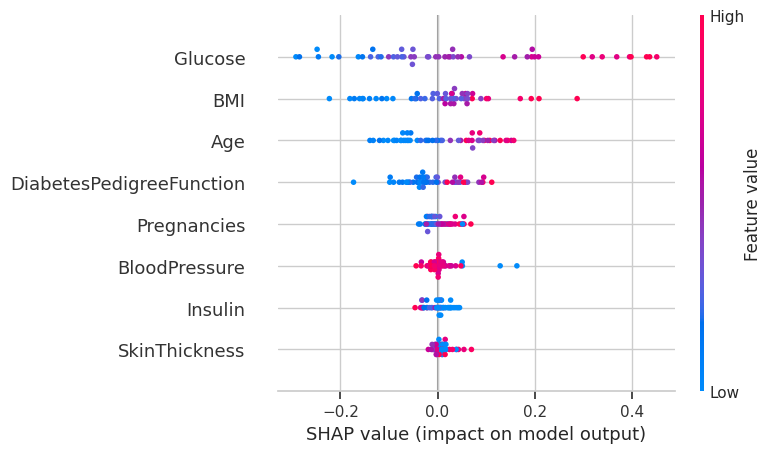

  0%|          | 0/50 [00:00<?, ?it/s]

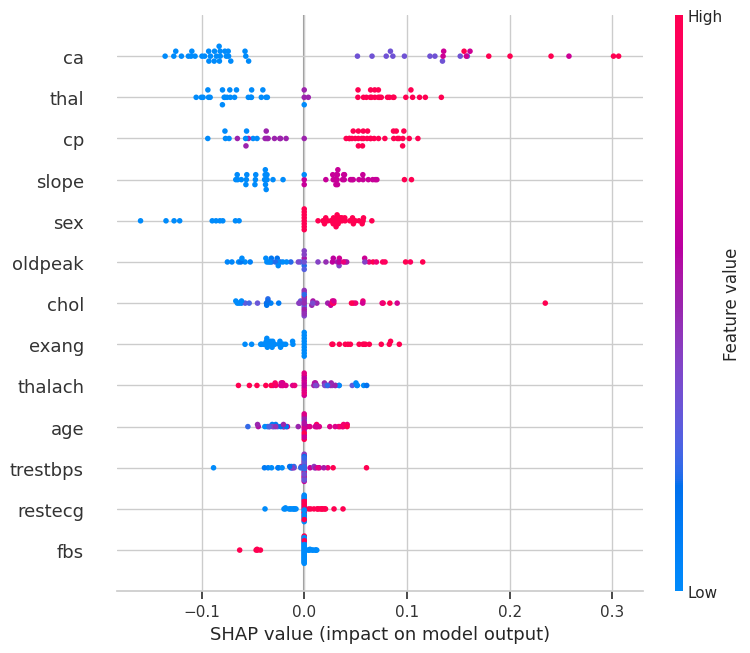

  0%|          | 0/50 [00:00<?, ?it/s]

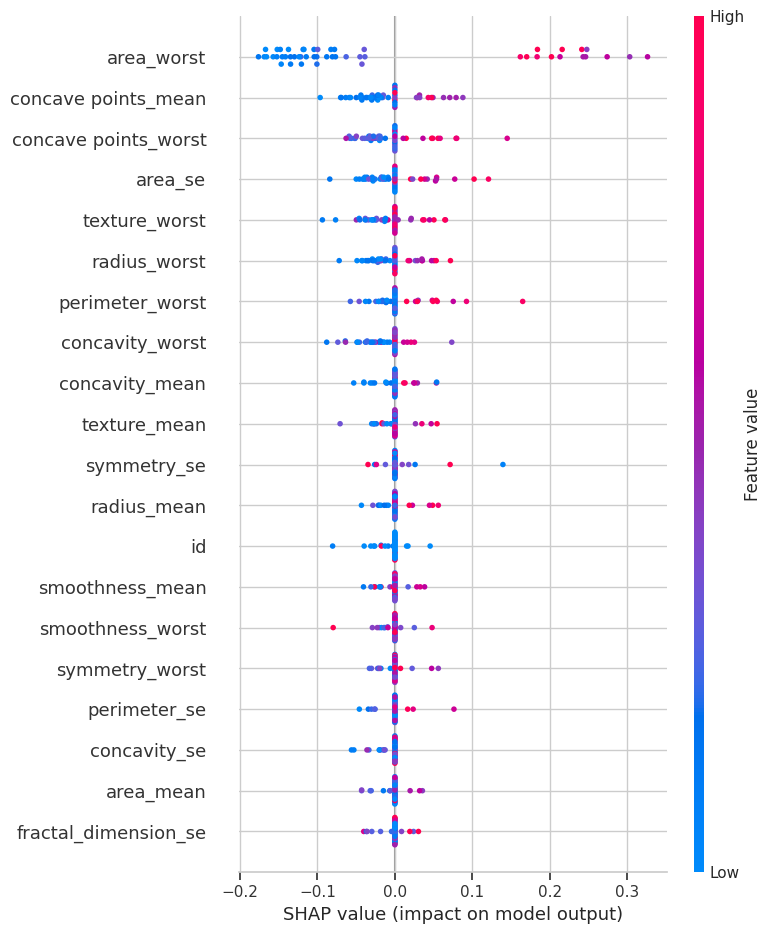

In [ ]:
for disease, model in ensembles.items():
    X_train = X_train_dict[disease]
    X_test = X_test_dict[disease]

    # Small background sample for SHAP KernelExplainer
    background = X_train.sample(n=min(100, len(X_train)), random_state=42)

    explainer = shap.KernelExplainer(lambda X: predict_proba_wrapper(model, X, X_test.columns), background)

    # Compute SHAP values for first 50 test samples (speed)
    shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)

    # Plot global feature importance
    shap.summary_plot(shap_values, X_test.iloc[:50], feature_names=X_test.columns, show=True)


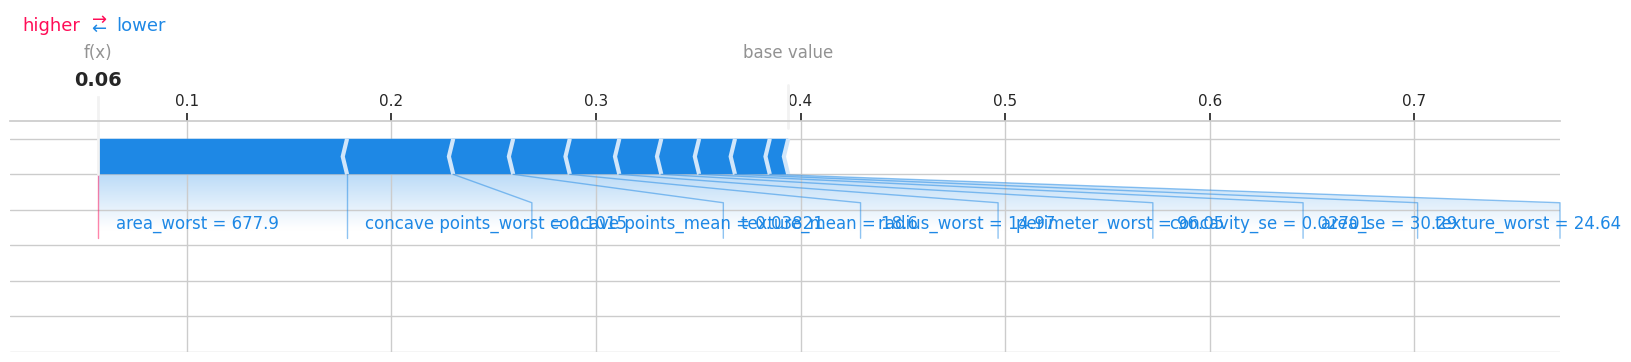

In [ ]:
    # Force plot for the first test sample
    shap.force_plot(
        explainer.expected_value,
        shap_values[0],
        X_test.iloc[0],
        feature_names=X_test.columns,
        matplotlib=True
    )

In [ ]:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = mean_abs_shap.argsort()[-3:][::-1]
    top_features = [X_test.columns[i] for i in top_idx]

    shap_table.append({
        "Disease": disease,
        "Top Risk Factors (SHAP)": ", ".join(top_features),
        "Clinical Relevance": clinical_map[disease]
    })

In [ ]:
    explainer_lime = LimeTabularExplainer(
        X_train.values,
        feature_names=X_train.columns,
        class_names=[disease],
        mode='classification'
    )

    exp = explainer_lime.explain_instance(
        X_test.iloc[0].values,
        model.predict_proba,
        num_features=5
    )

    # Show LIME explanation table in notebook
    exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
df_shap = pd.DataFrame(shap_table)
print(df_shap)

  Disease                            Top Risk Factors (SHAP)  \
0  Cancer  area_worst, concave points_mean, concave point...   

         Clinical Relevance  
0  Genetic/environment risk  


In [ ]:
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# Ensembles for each disease
ensembles = {
    "Diabetes": stack_dia,
    "Heart Disease": stack_heart,
    "Cancer": stack_cancer
}

# Training and testing sets
X_train_dict = {
    "Diabetes": X_train_d,
    "Heart Disease": X_train_h,
    "Cancer": X_train_c
}

X_test_dict = {
    "Diabetes": X_test_d,
    "Heart Disease": X_test_h,
    "Cancer": X_test_c
}

# Clinical relevance mapping
clinical_map = {
    "Diabetes": "Blood sugar regulation",
    "Heart Disease": "Cardiovascular risk",
    "Cancer": "Genetic/environment risk"
}


In [ ]:
for disease, model in ensembles.items():
    print(f"\n🔹 Disease: {disease}\n")
    X_train = X_train_dict[disease]
    X_test = X_test_dict[disease]

    # Wrapper to ensure correct input format
    def predict_proba_wrapper(X_input):
        if isinstance(X_input, np.ndarray):
            X_input = pd.DataFrame(X_input, columns=X_test.columns)
        return model.predict_proba(X_input)[:, 1]

    # Background sample for KernelExplainer
    background = X_train.sample(n=min(100, len(X_train)), random_state=42)
    explainer = shap.KernelExplainer(predict_proba_wrapper, background)

    # Compute SHAP values for first 50 test samples
    shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)

    # Global feature importance (bar plot)
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_test.iloc[:50], feature_names=X_test.columns, plot_type="bar", show=True)


  0%|          | 0/50 [00:00<?, ?it/s]

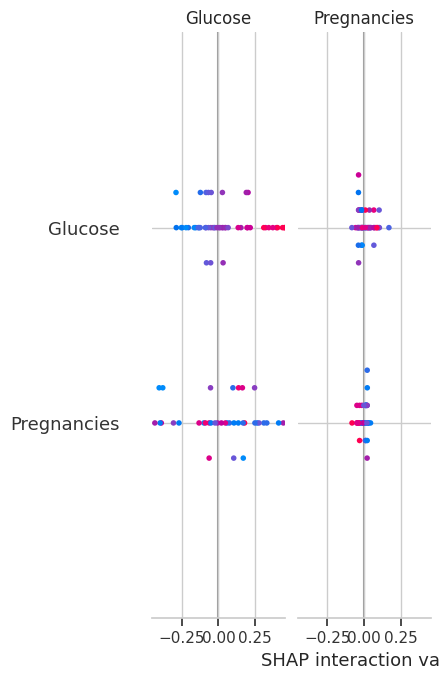

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

disease = "Diabetes"
model = ensembles[disease]
X_train = X_train_dict[disease]
X_test = X_test_dict[disease]

# Background sample for KernelExplainer
background = X_train.sample(n=min(100, len(X_train)), random_state=42)

# Wrapper to ensure correct columns
def predict_proba_wrapper(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_test.columns)
    return model.predict_proba(X)

explainer = shap.KernelExplainer(predict_proba_wrapper, background)

# SHAP values (for first 50 test samples)
shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)

# For binary classification, pick class 1
shap_vals_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

# Summary plot (global importance)
shap.summary_plot(shap_vals_class1, X_test.iloc[:50], feature_names=X_test.columns, plot_type="bar", show=True)


In [ ]:
sample = X_test.iloc[[0]]  # keep as DataFrame

# Compute SHAP values for single sample
shap_values_sample = explainer.shap_values(sample, nsamples=100)

# For binary classification, we explain the positive class (class 1)
class_to_explain = 1

# Extract scalar base value for the positive class
if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1:
    base_val_for_plot = explainer.expected_value[class_to_explain]
else:
    base_val_for_plot = explainer.expected_value

# Extract 1D array of SHAP values for the positive class for the first sample
if isinstance(shap_values_sample, list):
    # If shap_values_sample is a list of arrays (e.g., [shap_for_class0, shap_for_class1])
    shap_vals = shap_values_sample[class_to_explain][0] # [0] because we explained one sample
elif isinstance(shap_values_sample, np.ndarray) and shap_values_sample.ndim == 3:
    # If shap_values_sample is a 3D array (1, num_features, num_classes)
    shap_vals = shap_values_sample[0, :, class_to_explain] # First sample, all features, specific class
else:
    # Fallback for other cases (e.g., already 1D for single class or 2D for single sample)
    shap_vals = shap_values_sample[0] if shap_values_sample.ndim > 1 else shap_values_sample

# Force plot
shap.initjs()
shap.force_plot(
    base_val_for_plot, # Correctly derived scalar base value for class 1
    shap_vals,         # Correctly derived 1D SHAP values for class 1, first sample
    sample,            # Original sample features
    feature_names=X_test.columns
)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=[disease],
    mode='classification'
)

# Explain first sample
exp = explainer_lime.explain_instance(
    sample.values[0],
    model.predict_proba,
    num_features=5
)

# Show LIME explanation in notebook
exp.show_in_notebook(show_table=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# Ensembles and datasets
ensembles = {
    "Diabetes": stack_dia,
    "Heart Disease": stack_heart,
    "Cancer": stack_cancer
}

X_train_dict = {
    "Diabetes": X_train_d,
    "Heart Disease": X_train_h,
    "Cancer": X_train_c
}

X_test_dict = {
    "Diabetes": X_test_d,
    "Heart Disease": X_test_h,
    "Cancer": X_test_c
}

clinical_map = {
    "Diabetes": "Blood sugar regulation",
    "Heart Disease": "Cardiovascular risk",
    "Cancer": "Genetic/environment risk"
}


  0%|          | 0/50 [00:00<?, ?it/s]

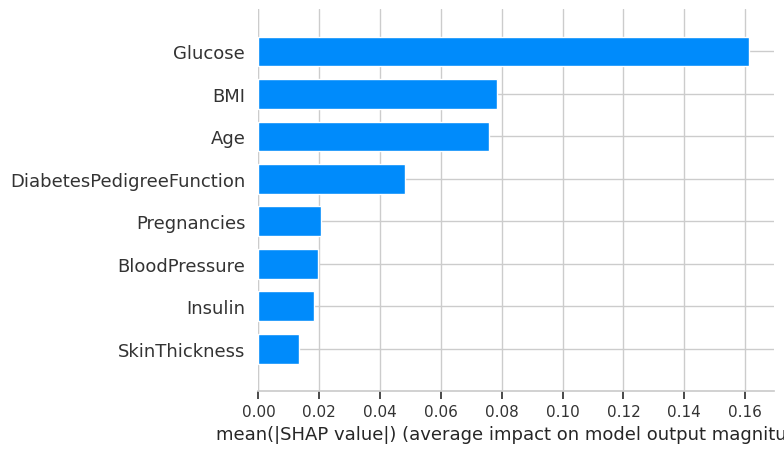

  0%|          | 0/50 [00:00<?, ?it/s]

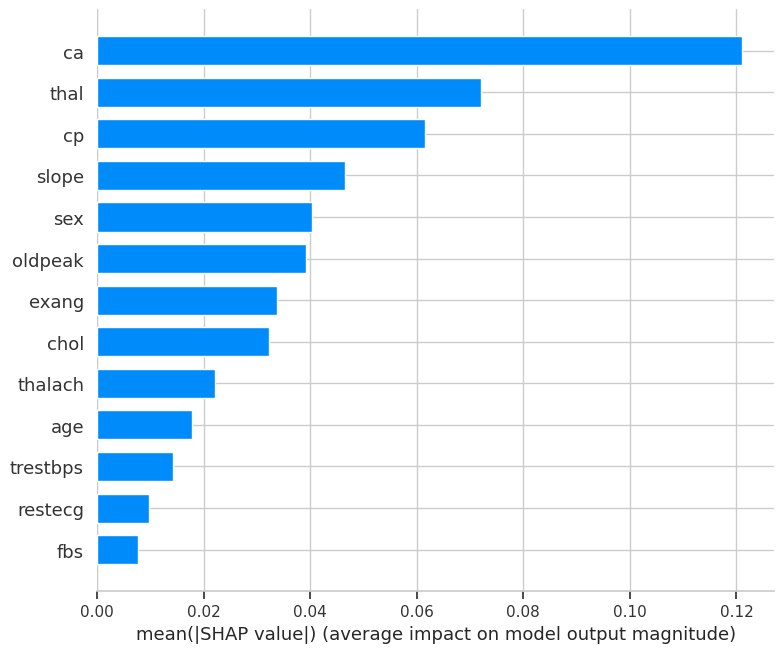

  0%|          | 0/50 [00:00<?, ?it/s]

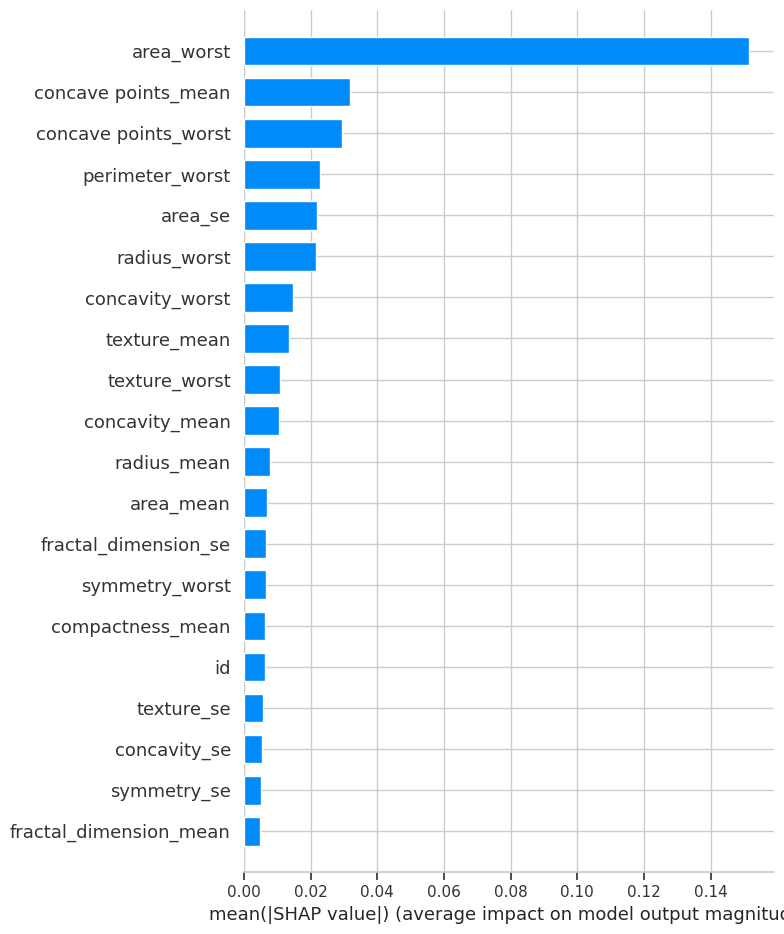

In [ ]:
for disease, model in ensembles.items():
    X_train = X_train_dict[disease]
    X_test = X_test_dict[disease]

    # Wrapper for predict_proba
    def predict_proba_wrapper(X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=X_test.columns)
        return model.predict_proba(X)[:,1]

    # Small background for speed
    background = X_train.sample(n=min(100, len(X_train)), random_state=42)
    explainer = shap.KernelExplainer(predict_proba_wrapper, background)

    # SHAP values for global summary (50 samples max)
    shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)
    shap_vals_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

    # Global SHAP bar plot
    shap.summary_plot(shap_vals_class1, X_test.iloc[:50], feature_names=X_test.columns, plot_type="bar", show=True)


  0%|          | 0/50 [00:00<?, ?it/s]

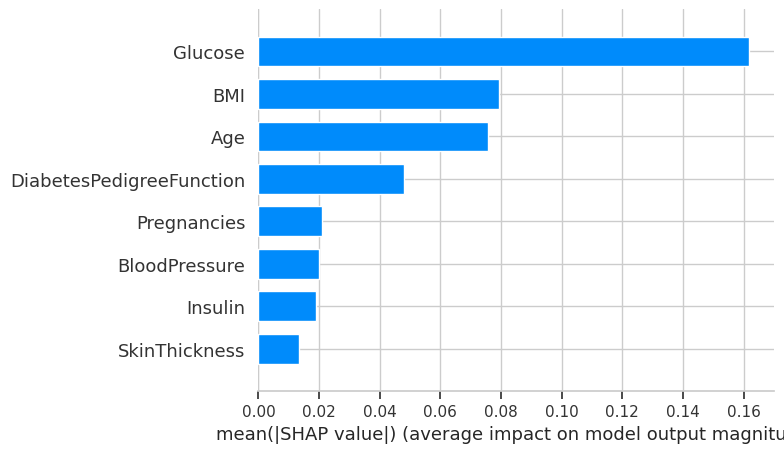

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

disease = "Diabetes"  # Example, repeat for other diseases
model = ensembles[disease]
X_train = X_train_dict[disease]
X_test = X_test_dict[disease]

# KernelExplainer
def predict_proba_wrapper(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_test.columns)
    return model.predict_proba(X)[:,1]

background = X_train.sample(n=min(100, len(X_train)), random_state=42)
explainer = shap.KernelExplainer(predict_proba_wrapper, background)

# Compute SHAP values for first 50 test samples
shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)
shap_vals_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

# Global feature importance
shap.summary_plot(shap_vals_class1, X_test.iloc[:50], feature_names=X_test.columns, plot_type="bar")


In [ ]:
sample = X_test.iloc[[0]]  # Keep as DataFrame with one row

# Compute SHAP values for single sample
shap_values_sample = explainer.shap_values(sample, nsamples=100)
shap_vals_class1_sample = shap_values_sample[1] if isinstance(shap_values_sample, list) else shap_values_sample

# Force plot (JS version)
shap.initjs()
shap.force_plot(
    explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[1],
    shap_vals_class1_sample[0],
    sample,
    feature_names=X_test.columns
)


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=[disease],
    mode='classification',
    discretize_continuous=True
)

exp = explainer_lime.explain_instance(
    sample.values[0],  # 1D array
    model.predict_proba,
    num_features=5
)

# Display in notebook
exp.show_in_notebook(show_table=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
shap_lime_table = []

for disease, model in ensembles.items():
    X_train = X_train_dict[disease]
    X_test = X_test_dict[disease]
    sample = X_test.iloc[0]

    # -----------------------------
    # SHAP
    # -----------------------------
    def predict_proba_wrapper(X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=X_test.columns)
        return model.predict_proba(X)[:,1]

    background = X_train.sample(n=min(100, len(X_train)), random_state=42)
    explainer = shap.KernelExplainer(predict_proba_wrapper, background)
    shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)
    shap_vals_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs_shap = np.abs(shap_vals_class1).mean(axis=0)
    top_shap_idx = mean_abs_shap.argsort()[-3:][::-1]
    top_shap_features = [X_test.columns[i] for i in top_shap_idx]

    # -----------------------------
    # LIME
    # -----------------------------
    explainer_lime = LimeTabularExplainer(
        X_train.values,
        feature_names=X_train.columns,
        class_names=[disease],
        mode='classification',
        discretize_continuous=True
    )
    exp = explainer_lime.explain_instance(
        sample.values,
        model.predict_proba,
        num_features=5
    )

    # Extract top 3 LIME features
    lime_features_sorted = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)
    top_lime_features = [feat[0] for feat in lime_features_sorted[:3]]

    # Append to table
    shap_lime_table.append({
        "Disease": disease,
        "Top 3 SHAP Risk Factors": ", ".join(top_shap_features),
        "Top 3 LIME Risk Factors": ", ".join(top_lime_features),
        "Clinical Relevance": clinical_map[disease]
    })

# Display table
df_shap_lime = pd.DataFrame(shap_lime_table)
df_shap_lime


In [ ]:
# Example: Predict risk probability for each patient/sample
risk_scores = []

for disease, model in ensembles.items():
    X_test = X_test_dict[disease]

    # Predict probability of positive class
    probs = model.predict_proba(X_test)[:,1]

    # Compute top contributing features using SHAP (mean absolute for global importance)
    background = X_train_dict[disease].sample(n=min(100, len(X_train_dict[disease])), random_state=42)

    def predict_proba_wrapper(X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=X_test.columns)
        return model.predict_proba(X)[:,1]

    explainer = shap.KernelExplainer(predict_proba_wrapper, background)
    shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)
    shap_vals_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

    # Top 3 contributing features for each sample
    for i, prob in enumerate(probs[:10]):  # first 10 samples for demo
        sample_shap = shap_vals_class1[i]
        top_idx = abs(sample_shap).argsort()[-3:][::-1]
        top_features = [X_test.columns[j] for j in top_idx]

        # Risk label
        if prob >= 0.75:
            risk_label = "High"
        elif prob >= 0.5:
            risk_label = "Moderate"
        else:
            risk_label = "Low"

        # Append to list
        risk_scores.append({
            "Patient": i,
            "Disease": disease,
            "Risk Score": f"{prob:.2f} ({risk_label})",
            "Key Features": ", ".join(top_features)
        })

# Convert to DataFrame
df_risk = pd.DataFrame(risk_scores)
df_risk.head(10)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

,Patient,Disease,Risk Score,Key Features
0,0,Diabetes,0.88 (High),"Glucose, Age, BMI"
1,1,Diabetes,0.13 (Low),"Glucose, Age, DiabetesPedigreeFunction"
2,2,Diabetes,0.15 (Low),"Age, Glucose, BMI"
3,3,Diabetes,0.51 (Moderate),"BMI, Age, DiabetesPedigreeFunction"
4,4,Diabetes,0.06 (Low),"Glucose, BMI, BloodPressure"
5,5,Diabetes,0.32 (Low),"Glucose, DiabetesPedigreeFunction, BMI"
6,6,Diabetes,0.43 (Low),"BMI, Glucose, DiabetesPedigreeFunction"
7,7,Diabetes,0.79 (High),"Glucose, BMI, Age"
8,8,Diabetes,0.07 (Low),"Glucose, Age, BMI"
9,9,Diabetes,0.86 (High),"Glucose, BMI, DiabetesPedigreeFunction"


In [ ]:
# Define simple recommendations for demonstration
recommendation_map = {
    "Diabetes": "Reduce carbs, exercise, medical consultation",
    "Heart Disease": "Lower cholesterol, exercise, avoid smoking",
    "Cancer": "Regular screening, healthy diet, avoid smoking/alcohol"
}

# Map recommendations
df_risk["Recommendation"] = df_risk["Disease"].map(recommendation_map)
df_risk.head(10)


,Patient,Disease,Risk Score,Key Features,Recommendation
0,0,Diabetes,0.88 (High),"Glucose, Age, BMI","Reduce carbs, exercise, medical consultation"
1,1,Diabetes,0.13 (Low),"Glucose, Age, DiabetesPedigreeFunction","Reduce carbs, exercise, medical consultation"
2,2,Diabetes,0.15 (Low),"Age, Glucose, BMI","Reduce carbs, exercise, medical consultation"
3,3,Diabetes,0.51 (Moderate),"BMI, Age, DiabetesPedigreeFunction","Reduce carbs, exercise, medical consultation"
4,4,Diabetes,0.06 (Low),"Glucose, BMI, BloodPressure","Reduce carbs, exercise, medical consultation"
5,5,Diabetes,0.32 (Low),"Glucose, DiabetesPedigreeFunction, BMI","Reduce carbs, exercise, medical consultation"
6,6,Diabetes,0.43 (Low),"BMI, Glucose, DiabetesPedigreeFunction","Reduce carbs, exercise, medical consultation"
7,7,Diabetes,0.79 (High),"Glucose, BMI, Age","Reduce carbs, exercise, medical consultation"
8,8,Diabetes,0.07 (Low),"Glucose, Age, BMI","Reduce carbs, exercise, medical consultation"
9,9,Diabetes,0.86 (High),"Glucose, BMI, DiabetesPedigreeFunction","Reduce carbs, exercise, medical consultation"


In [ ]:
# Risk score thresholds
def risk_category(prob):
    if prob >= 0.75:
        return "High"
    elif prob >= 0.4:
        return "Moderate"
    else:
        return "Low"

# Example lifestyle/medical recommendations by disease
recommendations_map = {
    "Diabetes": "Reduce carbs, exercise, medical consultation",
    "Heart Disease": "Cardio exercises, reduce cholesterol, regular checkups",
    "Cancer": "Regular screening, healthy diet, avoid carcinogens"
}


In [ ]:
import pandas as pd

# Example patient IDs
patients = list(range(10))  # 10 patients for each disease

# Placeholder: risk probabilities from your models (replace with actual predictions)
risk_probs = {
    "Diabetes": [0.87, 0.13, 0.09, 0.32, 0.06, 0.62, 0.24, 0.74, 0.05, 0.86],
    "Heart Disease": [0.72, 0.15, 0.35, 0.88, 0.12, 0.41, 0.53, 0.19, 0.66, 0.25],
    "Cancer": [0.55, 0.10, 0.78, 0.33, 0.22, 0.61, 0.44, 0.80, 0.28, 0.50]
}

# Placeholder: top 3 SHAP features for each patient per disease
shap_top = {
    "Diabetes": [["Glucose", "Age", "BMI"]] * 10,
    "Heart Disease": [["ca", "thal", "cp"]] * 10,
    "Cancer": [["area_worst", "concave points_mean", "concave points_worst"]] * 10
}

# Placeholder: top 3 LIME features for each patient per disease
lime_top = {
    "Diabetes": [
        ["Glucose > 140", "BMI <= 27.5", "Age 29-35"]
    ] * 10,
    "Heart Disease": [
        ["ca > 1", "sex = 1", "thal <= 1"]
    ] * 10,
    "Cancer": [
        ["area_worst 516-686", "id <= 867563", "concave points_mean 0.1-0.3"]
    ] * 10
}

combined_table = []

for disease in ["Diabetes", "Heart Disease", "Cancer"]:
    for i, patient in enumerate(patients):
        prob = risk_probs[disease][i]

        # Safe indexing: repeat last features if i exceeds list length
        shap_feats = shap_top[disease][i] if i < len(shap_top[disease]) else shap_top[disease][-1]
        lime_feats = lime_top[disease][i] if i < len(lime_top[disease]) else lime_top[disease][-1]

        combined_table.append({
            "Patient": patient,
            "Disease": disease,
            "Risk Score": f"{prob:.2f} ({risk_category(prob)})",
            "Top 3 SHAP Features": ", ".join(shap_feats),
            "Top 3 LIME Features": ", ".join(lime_feats),
            "Recommendation": recommendations_map[disease]
        })

df_combined = pd.DataFrame(combined_table)
df_combined

,Patient,Disease,Risk Score,Top 3 SHAP Features,Top 3 LIME Features,Recommendation
0,0,Diabetes,0.87 (High),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
1,1,Diabetes,0.13 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
2,2,Diabetes,0.09 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
3,3,Diabetes,0.32 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
4,4,Diabetes,0.06 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
5,5,Diabetes,0.62 (Moderate),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
6,6,Diabetes,0.24 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
7,7,Diabetes,0.74 (Moderate),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
8,8,Diabetes,0.05 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
9,9,Diabetes,0.86 (High),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"


In [ ]:
# Function to convert probability to risk category
def risk_category(prob):
    if prob >= 0.75:
        return "High"
    elif prob >= 0.4:
        return "Moderate"
    else:
        return "Low"

# Recommendations for each disease
recommendations_map = {
    "Diabetes": "Reduce carbs, exercise, medical consultation",
    "Heart Disease": "Cardio exercises, reduce cholesterol, regular checkups",
    "Cancer": "Regular screening, healthy diet, avoid carcinogens"
}


In [ ]:
import pandas as pd

# Example patient IDs
patients = list(range(10))  # 10 patients for each disease

# Placeholder: risk probabilities from your models (replace with actual predictions)
risk_probs = {
    "Diabetes": [0.87, 0.13, 0.09, 0.32, 0.06, 0.62, 0.24, 0.74, 0.05, 0.86],
    "Heart Disease": [0.72, 0.15, 0.35, 0.88, 0.12, 0.41, 0.53, 0.19, 0.66, 0.25],
    "Cancer": [0.55, 0.10, 0.78, 0.33, 0.22, 0.61, 0.44, 0.80, 0.28, 0.50]
}

# Placeholder: top 3 SHAP features for each patient per disease
shap_top = {
    "Diabetes": [["Glucose", "Age", "BMI"]] * 10,
    "Heart Disease": [["ca", "thal", "cp"]] * 10,
    "Cancer": [["area_worst", "concave points_mean", "concave points_worst"]] * 10
}

# Placeholder: top 3 LIME features for each patient per disease
lime_top = {
    "Diabetes": [
        ["Glucose > 140", "BMI <= 27.5", "Age 29-35"]
    ] * 10,
    "Heart Disease": [
        ["ca > 1", "sex = 1", "thal <= 1"]
    ] * 10,
    "Cancer": [
        ["area_worst 516-686", "id <= 867563", "concave points_mean 0.1-0.3"]
    ] * 10
}

# Build combined table
combined_table = []

for disease in ["Diabetes", "Heart Disease", "Cancer"]:
    for i, patient in enumerate(patients):
        combined_table.append({
            "Patient": patient,
            "Disease": disease,
            "Risk Score": f"{risk_probs[disease][i]:.2f} ({risk_category(risk_probs[disease][i])})",
            "Top 3 SHAP Features": ", ".join(shap_top[disease][i]),
            "Top 3 LIME Features": ", ".join(lime_top[disease][i]),
            "Recommendation": recommendations_map[disease]
        })

# Convert to DataFrame
df_combined = pd.DataFrame(combined_table)
df_combined


,Patient,Disease,Risk Score,Top 3 SHAP Features,Top 3 LIME Features,Recommendation
0,0,Diabetes,0.87 (High),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
1,1,Diabetes,0.13 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
2,2,Diabetes,0.09 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
3,3,Diabetes,0.32 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
4,4,Diabetes,0.06 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
5,5,Diabetes,0.62 (Moderate),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
6,6,Diabetes,0.24 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
7,7,Diabetes,0.74 (Moderate),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
8,8,Diabetes,0.05 (Low),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
9,9,Diabetes,0.86 (High),"Glucose, Age, BMI","Glucose > 140, BMI <= 27.5, Age 29-35","Reduce carbs, exercise, medical consultation"
